* Cargar un archivo .csv con señales EEG simuladas o reales (por ejemplo, bases como EEG Eye State, OpenBCI o datos sintéticos).
* Visualizar el comportamiento de la señal en el tiempo (plot de amplitud vs tiempo).
* Aplicar filtros pasa banda para aislar frecuencias Alpha (8–12 Hz) o Beta (12–30 Hz) usando scipy.signal.
* Definir una condición artificial de control, como un “nivel de atención” (e.g., potencia en banda Alpha > umbral).
* Simular una acción visual básica:

* Cambiar el color de una ventana.
* Mover un objeto en pantalla.
* Mostrar un indicador si se alcanza cierta activación cerebral simulada.

In [2]:
# Importamos las librerías necesarias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import butter, lfilter, welch
from IPython.display import display, HTML
import matplotlib.patches as patches
import time

In [9]:
# Establecemos unos parámetros para generar datos
fs = 250  # Frecuencia de muestreo en Hz
duracion = 10  # Duración en segundos
t = np.linspace(0, duracion, fs * duracion)

# Creamos los componentes de señal EEG
alpha_wave = 50 * np.sin(2 * np.pi * 10 * t)  # 10 Hz (Alpha)
beta_wave = 20 * np.sin(2 * np.pi * 20 * t)   # 20 Hz (Beta)
ruido = np.random.normal(0, 10, len(t))       # Ruido blanco

# Combinamos los componentes
eeg_sintetica = alpha_wave + beta_wave + ruido

# Crear DataFrame de pandas para poder manejarlo
df = pd.DataFrame({'time': t, 'eeg': eeg_sintetica})


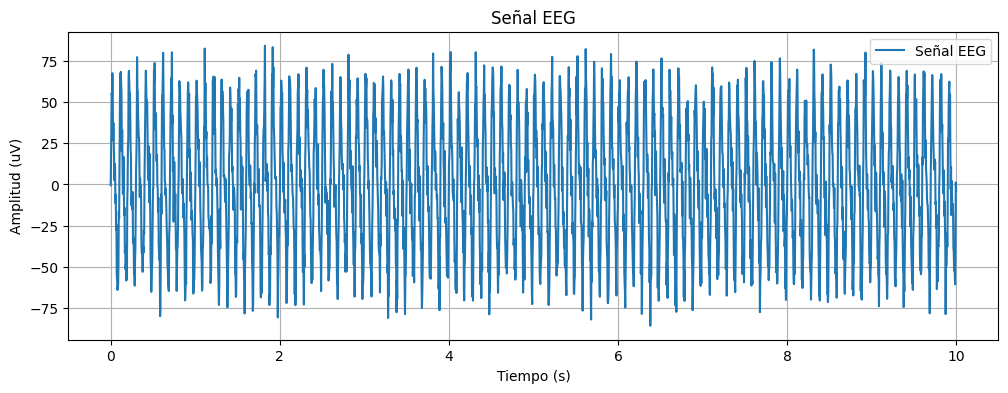

In [10]:
# Graficamos la señal
plt.figure(figsize=(12, 4))
plt.plot(df['time'], df['eeg'], label='Señal EEG')
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud (uV)')
plt.title('Señal EEG')
plt.grid(True)
plt.legend()
plt.show()

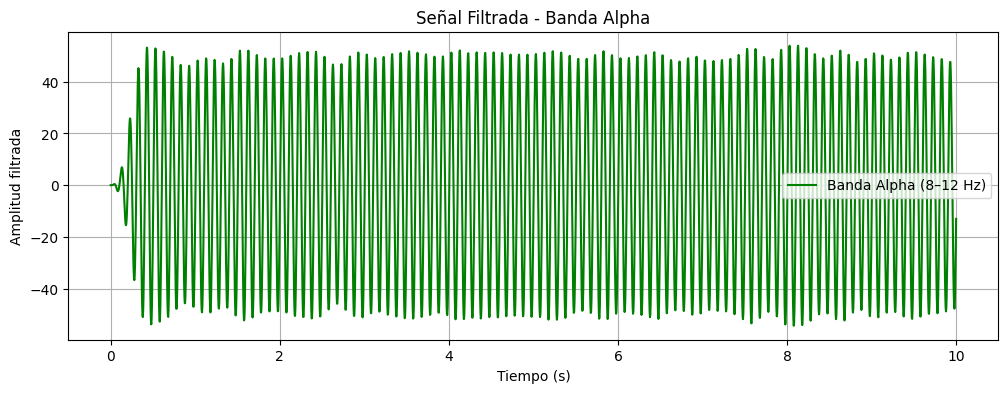

In [5]:
def butter_bandpass(lowcut, highcut, fs, order=4):
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype='band')
    return b, a

def apply_bandpass_filter(data, lowcut, highcut, fs):
    b, a = butter_bandpass(lowcut, highcut, fs)
    return lfilter(b, a, data)

# Definir parámetros
fs = 250  # Frecuencia de muestreo (Hz), ajústalo según tus datos
eeg_signal = df['eeg'].values

# Filtrar banda Alpha
alpha_signal = apply_bandpass_filter(eeg_signal, 8, 12, fs)

# Visualizar señal filtrada
plt.figure(figsize=(12, 4))
plt.plot(df['time'], alpha_signal, label='Banda Alpha (8–12 Hz)', color='green')
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud filtrada')
plt.title('Señal Filtrada - Banda Alpha')
plt.grid(True)
plt.legend()
plt.show()

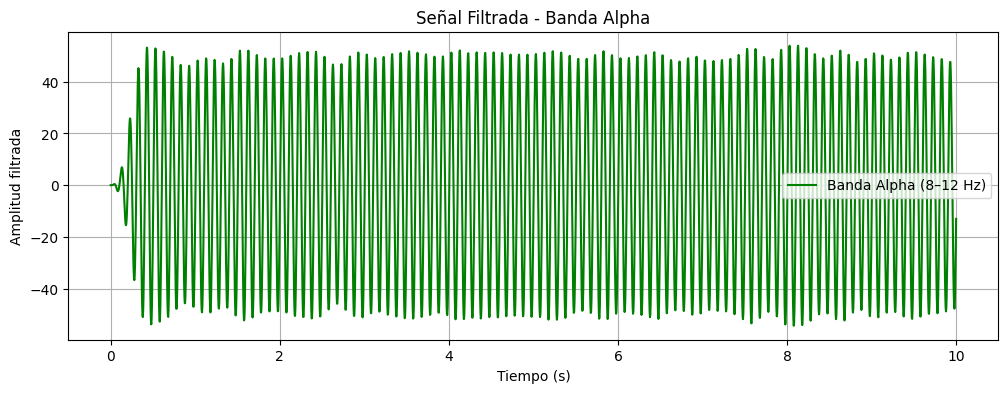

In [6]:
# Filtramos la señal para discriminar las bandas Alpha y Beta
def butter_bandpass(lowcut, highcut, fs, order=4):
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype='band')
    return b, a

def apply_bandpass_filter(data, lowcut, highcut, fs):
    b, a = butter_bandpass(lowcut, highcut, fs)
    return lfilter(b, a, data)

# Definir parámetros
fs = 250  # Frecuencia de muestreo (Hz), ajústalo según tus datos
eeg_signal = df['eeg'].values

# Filtrar banda Alpha
alpha_signal = apply_bandpass_filter(eeg_signal, 8, 12, fs)

# Visualizar señal filtrada
plt.figure(figsize=(12, 4))
plt.plot(df['time'], alpha_signal, label='Banda Alpha (8–12 Hz)', color='green')
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud filtrada')
plt.title('Señal Filtrada - Banda Alpha')
plt.grid(True)
plt.legend()
plt.show()

In [12]:
# Calcular la potencia de la banda Alpha usando Welch
f, Pxx = welch(alpha_signal, fs, nperseg=1024)

# Calcular potencia total en banda Alpha
alpha_band = (f >= 8) & (f <= 12)
alpha_power = np.trapezoid(Pxx[alpha_band], f[alpha_band])
print(f"Potencia Alpha: {alpha_power:.4f}")

# Definir un umbral de atención
attention_threshold = 0.5  # Ajusta este valor según tus datos
attention_detected = alpha_power > attention_threshold
print("¿Nivel de atención alto?", attention_detected)

Potencia Alpha: 1262.7152
¿Nivel de atención alto? True


/usr/local/lib/python3.11/dist-packages/scipy/signal/_spectral_py.py:790: UserWarning: nperseg = 256 is greater than input length  = 250, using nperseg = 250
  freqs, _, Pxy = _spectral_helper(x, y, fs, window, nperseg, noverlap,
<ipython-input-15-9cf24d54a5fd>:16: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  alpha_power = np.trapz(Pxx[alpha_band], f[alpha_band])


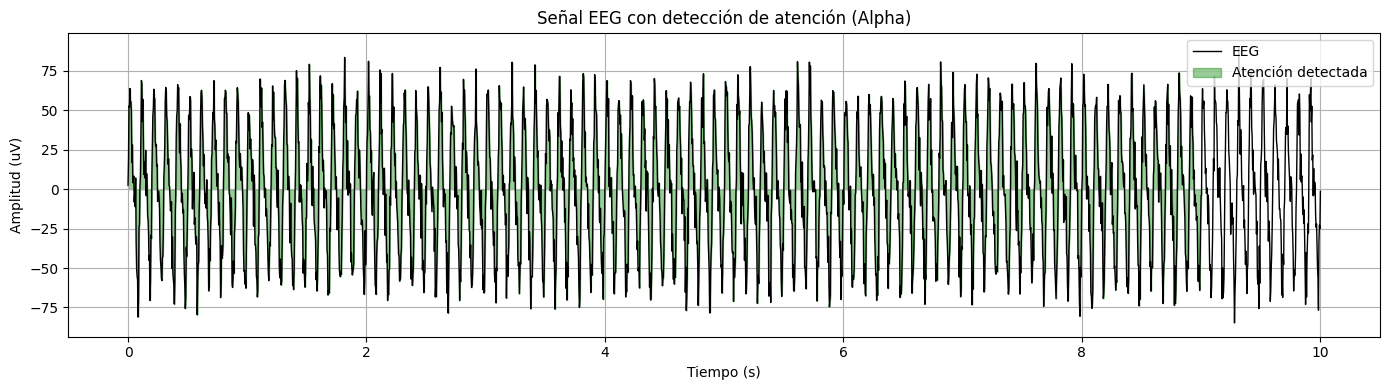

In [15]:
fs = 250  # Frecuencia de muestreo
window_sec = 1  # Ventana de 1 segundo
window_size = fs * window_sec
attention_threshold = 0.5  # Ajusta esto según tu señal

# Crear una lista para marcar detección de atención en cada ventana
attention_mask = np.zeros_like(eeg_signal, dtype=bool)

# Evaluar potencia alpha en ventanas móviles
for start in range(0, len(eeg_signal) - window_size, window_size):
    end = start + window_size
    window = eeg_signal[start:end]
    alpha_window = apply_bandpass_filter(window, 8, 12, fs)
    f, Pxx = welch(alpha_window, fs, nperseg=256)
    alpha_band = (f >= 8) & (f <= 12)
    alpha_power = np.trapz(Pxx[alpha_band], f[alpha_band])
    if alpha_power > attention_threshold:
        attention_mask[start:end] = True

# Plot de la señal completa con zonas de atención resaltadas
plt.figure(figsize=(14, 4))
plt.plot(df['time'], eeg_signal, label='EEG', color='black', linewidth=1)

# Resaltar zonas de atención
plt.fill_between(df['time'], eeg_signal, where=attention_mask, color='green'
                , alpha=0.4, label='Atención detectada')

plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud (uV)')
plt.title('Señal EEG con detección de atención (Alpha)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()